# Spatial Polygon Merging (SPM) Benchmarking

This notebook is used to benchmark the merging performance of the SPM algorithm against other merging methods on images of various sizes. The test dataset is generated by cropping a large image into smaller tiles of different sizes. A fine-tuned model is then used to predict the segmentations in each tile, and fragmented predictions are merged using the SPM algorithm and other methods. The merging performance for each method is then evaluated based on the mAP, precision, recall, and F1-score of the merged polygons compared to the ground truth polygons.

### Benchmark Test Dataset Generation

The WHU Building Dataset provides an uncropped version of the dataset, which contains a large aerial image and its corresponding shapefile of building polygons. The image and shapefile is downloaded and stored in the `test_images` folder. The image and shapefile are then passed to the `generate` command of the benchmark module, which crops the image into smaller tiles of different sizes and saves them in the `benchmark_test_set` folder. Below are the links to download the original image and shapefile:

- [Whole Image File](https://gpcv.whu.edu.cn/data/1.the%20whole%20aerial%20image.tif)
- [Shapefile](https://gpcv.whu.edu.cn/data/2.%20The%20shape%20file%20of%20the%20whole%20area.zip)

In [ ]:
!cd ../ && \
uv run python -m benchmark generate \
"test_images/1.the whole aerial image.tif" \
"test_images/2. The shape file of the whole area/allbuilding.shp" \
benchmark_test_set \
--crop-sizes 3000 5000 10000 20000 50000 100000 \
--stride-ratio 1.0 \
--max-crops 1

[2026-07-13 09:55:48.922470] WARNING - Repairing 4 invalid label geometries (/media/vince/Backup/Projects/spatial_polygon_merging/benchmark/crops.py:65:generate_test_set())
[2026-07-13 09:56:00.102950] INFO - Created 412 records (/media/vince/Backup/Projects/spatial_polygon_merging/.venv/lib/python3.11/site-packages/pyogrio/raw.py:733:write())
[2026-07-13 09:56:00.105718] INFO - Wrote crop benchmark_test_set/crop_5000_0/image.tif with 412 labels (/media/vince/Backup/Projects/spatial_polygon_merging/benchmark/crops.py:100:generate_test_set())
[2026-07-13 09:56:08.371832] INFO - Created 1,505 records (/media/vince/Backup/Projects/spatial_polygon_merging/.venv/lib/python3.11/site-packages/pyogrio/raw.py:733:write())
[2026-07-13 09:56:08.375627] INFO - Wrote crop benchmark_test_set/crop_10000_0/image.tif with 1505 labels (/media/vince/Backup/Projects/spatial_polygon_merging/benchmark/crops.py:100:generate_test_set())
[2026-07-13 09:56:26.490117] INFO - Created 5,250 records (/media/vince/B

### Benchmark Report Generation (CLI)

In [4]:
!cd ../ && \
uv run python -m benchmark evaluate \
benchmark_test_set \
"runs/segment/yolo-seg-whu/weights/best.pt" \
--device cuda \
--batch-size 4 \
--conf 0.3 \
--tile-size 1500 \
--overlap 0.1 \
--iou 0.5 \
--output notebooks/results2/benchmark_results.csv

[2026-07-17 13:21:14.444208] INFO - Benchmarking 6 crops with 7 methods (/media/vince/Backup/Projects/spatial_polygon_merging/benchmark/runner.py:39:benchmark_test_set())
[2026-07-17 13:21:14.461487] INFO - Performing prediction on image: benchmark_test_set/crop_100000_0/image.tif (width: 100000, height: 100000) (/media/vince/Backup/Projects/spatial_polygon_merging/src/spm/models/yolo.py:79:predict())
[2026-07-17 13:26:55.521185] INFO - Total tiles processed: 5476 (/media/vince/Backup/Projects/spatial_polygon_merging/src/spm/models/yolo.py:169:predict())
[2026-07-17 13:27:00.638661] INFO - Running SPM with config: SPMConfig(tau_dist=1.0, tau_chain=5), merge_only_seam=True (/media/vince/Backup/Projects/spatial_polygon_merging/benchmark/methods.py:167:merge_spm())
[2026-07-17 13:27:00.639724] INFO - Indexing polygons for merging (/media/vince/Backup/Projects/spatial_polygon_merging/src/spm/merging/spm.py:20:index())
[2026-07-17 13:27:32.275096] INFO - Created 61,470 records (/media/vince

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [15]:
# Load benchmark results
df = pd.read_csv("results/benchmark_results.csv")
df.sort_values(by=["crop_size", "method"], inplace=True, ignore_index=True)
df

,crop,crop_size,method,merge_time,peak_memory_usage,num_gt,num_pred,mAP,mAP50,mAP75,precision,recall,f1
0,crop_3000_0,3000,sahi_greedy_nmm,0.114493,44.675781,191,197,0.496135,0.814140,0.585913,0.822335,0.848168,0.835052
1,crop_3000_0,3000,sahi_lsnms,6.132196,226.691406,191,197,0.488549,0.807955,0.592251,0.817259,0.842932,0.829897
2,crop_3000_0,3000,sahi_nmm,0.132762,44.570312,191,196,0.496170,0.814243,0.585946,0.826531,0.848168,0.837209
3,crop_3000_0,3000,sahi_nms,0.005880,43.769531,191,197,0.488549,0.807955,0.592251,0.817259,0.842932,0.829897
4,crop_3000_0,3000,smm,39.318653,5087.765625,191,189,0.490957,0.819894,0.554573,0.857143,0.848168,0.852632
5,crop_3000_0,3000,spm_global,0.043741,2.406250,191,181,0.501271,0.817710,0.589730,0.883978,0.837696,0.860215
6,crop_3000_0,3000,spm_seam_only,0.043325,2.308594,191,182,0.501866,0.818113,0.589839,0.879121,0.837696,0.857909
7,crop_5000_0,5000,sahi_greedy_nmm,0.180344,54.546875,416,470,0.551469,0.865222,0.640874,0.806383,0.911058,0.855530
8,crop_5000_0,5000,sahi_lsnms,6.141576,225.058594,416,470,0.507563,0.831419,0.572477,0.795745,0.899038,0.844244
9,crop_5000_0,5000,sahi_nmm,0.191309,54.710938,416,465,0.552109,0.859982,0.642642,0.812903,0.908654,0.858116


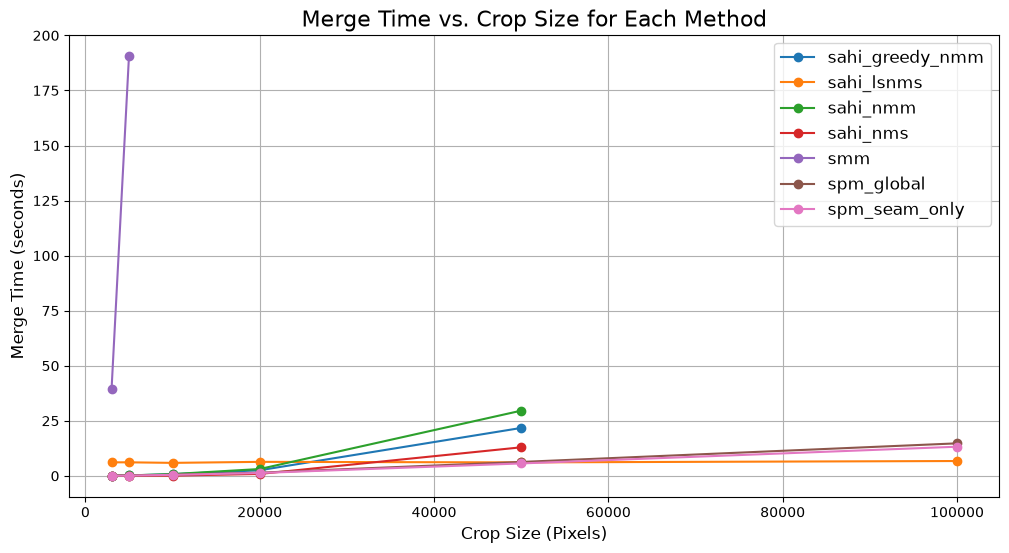

In [18]:
# Visualize merge_time vs. crop_size for each method
plt.figure(figsize=(12, 6))
for method in df["method"].unique():
    method_data = df[df["method"] == method]
    plt.plot(method_data["crop_size"], method_data["merge_time"], marker='o', label=method)
plt.title("Merge Time vs. Crop Size for Each Method", fontsize=16)
plt.xlabel("Crop Size (Pixels)", fontsize=12)
plt.ylabel("Merge Time (seconds)", fontsize=12)
plt.legend(fontsize=12)
plt.grid()
plt.savefig("results/merge_time_vs_crop_size.png")
plt.show()

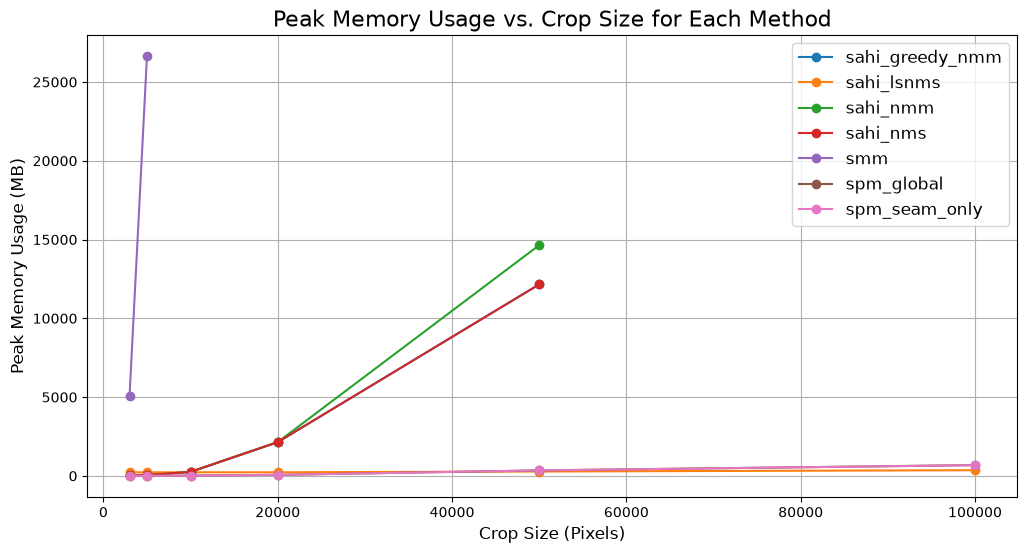

In [19]:
# Visualize peak_memory_usage vs. number of polygons for each method
plt.figure(figsize=(12, 6))
for method in df["method"].unique():
    method_data = df[df["method"] == method]
    plt.plot(method_data["crop_size"], method_data["peak_memory_usage"], marker='o', label=method)
plt.title("Peak Memory Usage vs. Crop Size for Each Method", fontsize=16)
plt.xlabel("Crop Size (Pixels)", fontsize=12)
plt.ylabel("Peak Memory Usage (MB)", fontsize=12)
plt.legend(fontsize=12)
plt.grid()
plt.savefig("results/peak_memory_usage_vs_crop_size.png")
plt.show()

In [21]:
# Get the metrics for each method at the 5000 crop size (where all methods have results)
df_metrics_5000 = df[df["crop_size"] == 5000][["method","mAP", "mAP50", "mAP75", "precision", "recall", "f1"]]
df_metrics_5000

,method,mAP,mAP50,mAP75,precision,recall,f1
7,sahi_greedy_nmm,0.551469,0.865222,0.640874,0.806383,0.911058,0.855530
8,sahi_lsnms,0.507563,0.831419,0.572477,0.795745,0.899038,0.844244
9,sahi_nmm,0.552109,0.859982,0.642642,0.812903,0.908654,0.858116
10,sahi_nms,0.507563,0.831419,0.572477,0.795745,0.899038,0.844244
11,smm,0.559074,0.893987,0.631021,0.884977,0.906250,0.895487
12,spm_global,0.562491,0.874279,0.649131,0.911330,0.889423,0.900243
13,spm_seam_only,0.564361,0.883518,0.656336,0.907090,0.891827,0.899394


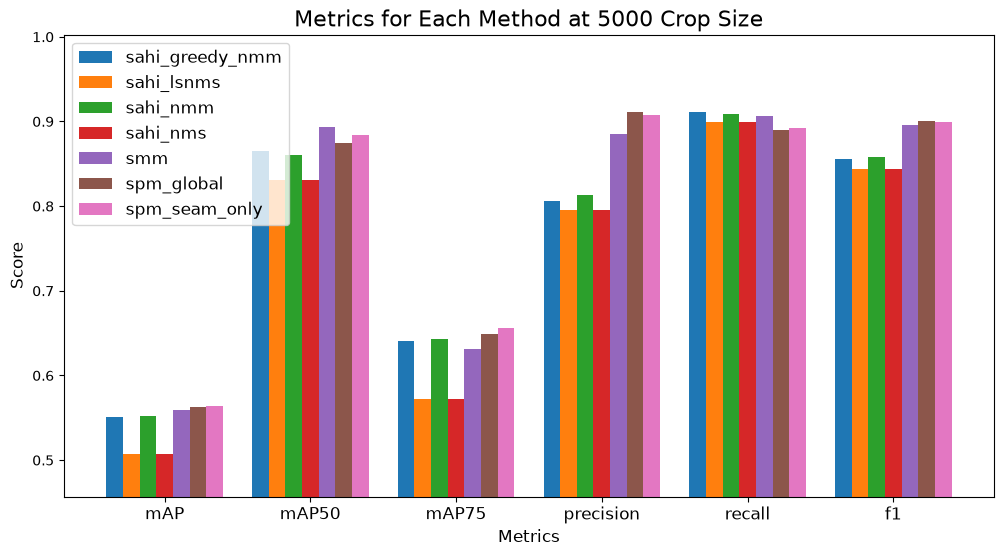

In [26]:
categories = df_metrics_5000.columns[1:]
n = len(df_metrics_5000)
x = np.arange(len(categories))
# print(f"Categories: {categories}, Number of methods: {n}, X positions: {x}")
width = 0.8 / n

fig, ax = plt.subplots(figsize=(12, 6))

for i, (_, row) in enumerate(df_metrics_5000.iterrows()):
    offset = (i - (n - 1) / 2) * width
    # print(f"Row: {row['method']}, Offset: {offset}, Width: {width}, X positions: {x + offset}")
    ax.bar(x+offset, row[categories], width=width, label=row["method"], align='center', bottom=None)

ax.set_xticks(x)
ax.set_ylim(df_metrics_5000[categories].min().values.min() * 0.9, df_metrics_5000[categories].max().values.max() * 1.1)
ax.set_xticklabels(categories, fontsize=12)
ax.legend(fontsize=12)
ax.set_title("Metrics for Each Method at 5000 Crop Size", fontsize=16)
ax.set_xlabel("Metrics", fontsize=12)
ax.set_ylabel("Score", fontsize=12)
plt.savefig("results/metrics_for_each_method_at_5000_crop_size.png")

## Compare SPM Merge Quality Over Varying Values of Proximity Threshold and BFS Depth Threshold

The SPM algorithm have two main parameters that determine the merging quality: the proximity threshold and the BFS depth threshold. To evaluate how these values affect the merging qualiuty, we will run a benchmark test on an unmerged prediction of an image of a fix crop size of 50000 pixels, and vary the proximity threshold and BFS depth threshold values. The benchmark report will be generated in the `results` folder.

In [1]:
import sys

sys.path.append("../")

In [4]:
from dataclasses import asdict
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

from benchmark.eval import evaluate_prediction
from benchmark.methods import merge_spm
from benchmark.runner import _write_csv
from spm.config import SPMConfig, ModelConfig
from spm.models.yolo import YOLOModel

In [3]:
test_image_path = "../benchmark_test_set/crop_50000_0/image.tif"
test_label_path = "../benchmark_test_set/crop_50000_0/labels.gpkg"

report_path = Path("results/benchmark_prox_bfs_report.csv")

In [ ]:
config = ModelConfig(
    model_path="../runs/segment/yolo-seg-whu/weights/best.pt",
    device="cuda",
    batch_size=4,
    confidence_threshold=0.3,
    tile_size=1500,
    overlap=0.1,
    iou_threshold=0.5
)

model = YOLOModel(config)
unmerged = model(test_image_path, merge=False)

[2026-07-15 16:09:52.028813] INFO - Performing prediction on image: ../benchmark_test_set/crop_50000_0/image.tif (width: 50000, height: 50000) (/media/vince/Backup/Projects/spatial_polygon_merging/src/spm/models/yolo.py:79:predict())
[2026-07-15 16:11:25.757643] INFO - Total tiles processed: 1369 (/media/vince/Backup/Projects/spatial_polygon_merging/src/spm/models/yolo.py:169:predict())


In [6]:
prox_values = [1.0, 2.0, 4.0, 8.0, 16.0]
bfs_depth_values = [1, 2, 3, 4, 5]

In [ ]:
rows = []
for prox in prox_values:
    for bfs_depth in bfs_depth_values:
        spm_config = SPMConfig(tau_dist=prox, rho_chain=bfs_depth)
        merged, _ = merge_spm(unmerged, spm_config)
        metrics = evaluate_prediction(merged, test_label_path)
        rows.append({
            "proximity_threshold": prox,
            "bfs_depth_threshold": bfs_depth,
            **asdict(metrics)
            })
        
_write_csv(rows, report_path)

[2026-07-15 16:11:28.565939] INFO - Running SPM with config: SPMConfig(tau_dist=1.0, tau_chain=1), merge_only_seam=False (/media/vince/Backup/Projects/spatial_polygon_merging/notebooks/../benchmark/methods.py:167:merge_spm())
[2026-07-15 16:11:28.566524] INFO - Indexing polygons for merging (/media/vince/Backup/Projects/spatial_polygon_merging/src/spm/merging/spm.py:20:index())
[2026-07-15 16:11:42.697548] INFO - Running SPM with config: SPMConfig(tau_dist=1.0, tau_chain=2), merge_only_seam=False (/media/vince/Backup/Projects/spatial_polygon_merging/notebooks/../benchmark/methods.py:167:merge_spm())
[2026-07-15 16:11:42.698257] INFO - Indexing polygons for merging (/media/vince/Backup/Projects/spatial_polygon_merging/src/spm/merging/spm.py:20:index())
[2026-07-15 16:11:54.893529] INFO - Running SPM with config: SPMConfig(tau_dist=1.0, tau_chain=3), merge_only_seam=False (/media/vince/Backup/Projects/spatial_polygon_merging/notebooks/../benchmark/methods.py:167:merge_spm())
[2026-07-15 

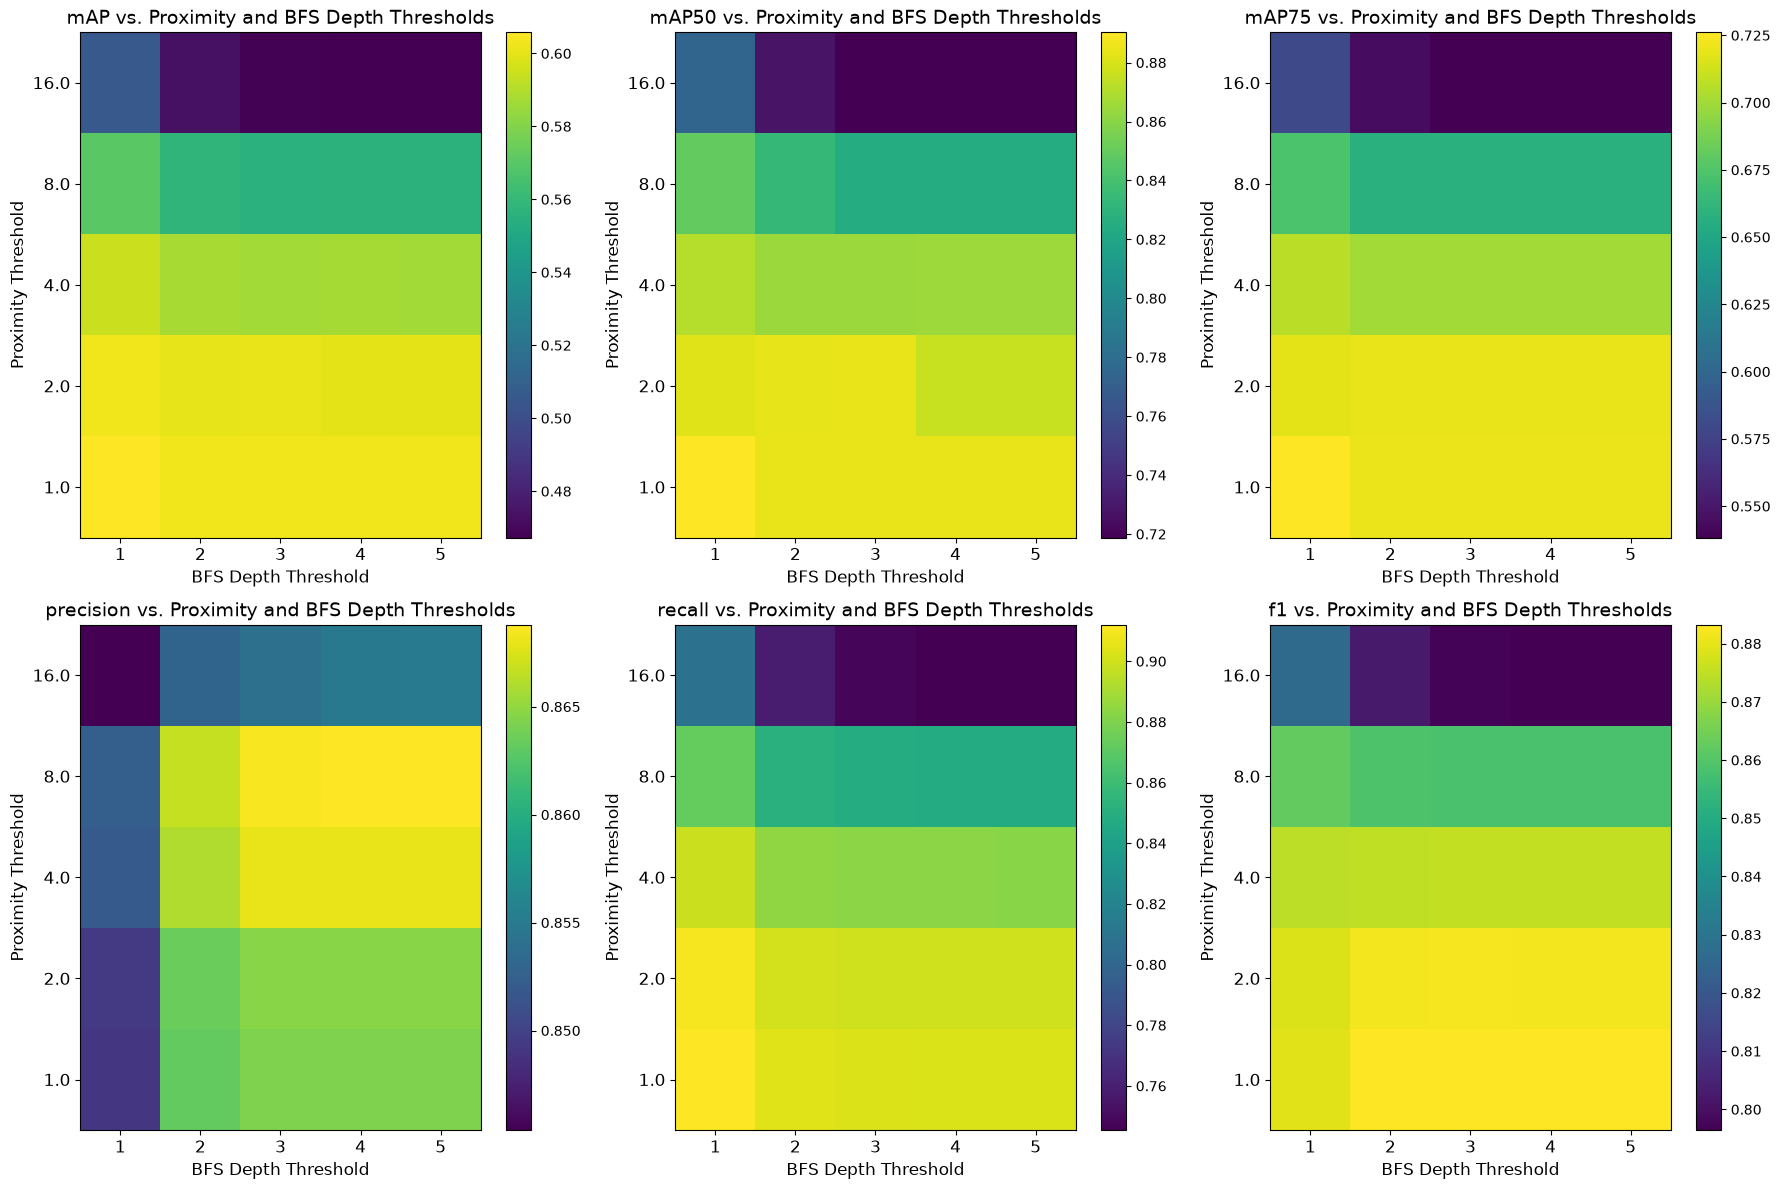

In [13]:
# Visualize the metrics for varying proximity and BFS depth thresholds
df = pd.read_csv(report_path)

fig, ax = plt.subplots(2, 3, figsize=(18, 12))
metrics = ["mAP", "mAP50", "mAP75", "precision", "recall", "f1"]
for i, metric in enumerate(metrics):
    row = i // 3
    col = i % 3
    pivot_table = df.pivot(index="proximity_threshold", columns="bfs_depth_threshold", values=metric)
    cax = ax[row, col].imshow(pivot_table, cmap='viridis', aspect='auto', origin='lower')
    ax[row, col].set_title(f"{metric} vs. Proximity and BFS Depth Thresholds", fontsize=14)
    ax[row, col].set_xlabel("BFS Depth Threshold", fontsize=12)
    ax[row, col].set_ylabel("Proximity Threshold", fontsize=12)
    ax[row, col].set_xticks(range(len(bfs_depth_values)))
    ax[row, col].set_xticklabels(bfs_depth_values, fontsize=12)
    ax[row, col].set_yticks(range(len(prox_values)))
    ax[row, col].set_yticklabels(prox_values, fontsize=12)
    fig.colorbar(cax, ax=ax[row, col], orientation='vertical')
plt.tight_layout()
plt.savefig("results/metrics_vs_prox_bfs_depth_thresholds.png")